# Whole-Head Pipeline — Skin-Driven Registration

Registers the template's skin surface to the subject's skin surface, then
propagates that single deformation field to every node in the mesh (skull,
brain, jaw, teeth, skin). No frozen regions.

**Known gap:** no cavity-constraint check — brain/skull interpenetration is
possible and not verified. Mesh QA only catches per-element folding, not
cross-tissue overlap.

```
skin driving surface (template) -> registered to subject skin
        -> TPS field fit on skin correspondence
        -> applied to every node in the mesh
```

Stages: 0 center -> 0.5b Kabsch seed (if landmarks) -> 1 PCA (skipped if
seeded) -> 2 rigid CPD -> 3 affine CPD -> 4 deformable CPD -> 5 TPS (skin +
whole mesh) -> 6 ICP refine (skin) -> 6.5 do-no-harm blend (skin) -> 5b TPS
rebuild from refined skin, applied to whole mesh -> 7 validation -> save.

## Setup

In [2]:
!pip install pycpd pyvista numpy scipy matplotlib pandas -q

import os, sys
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial import cKDTree
from scipy.interpolate import RBFInterpolator
from pycpd import RigidRegistration, AffineRegistration, DeformableRegistration

np.random.seed(0)
print('pyvista:', pv.__version__)
print('numpy  :', np.__version__)


pyvista: 0.48.4
numpy  : 2.2.5


## Configuration

`SUBJECT_LANDMARKS_PATH` -- SAM3D output, Nx3. Falls back to a subsampled
placeholder surface until that exists.

In [40]:
BASE_DIR = r'/home/asusry7/Desktop/New_version/New_version'

TEMPLATE_K    = os.path.join(BASE_DIR, 'Data/Ls_dyna_model/Head_V6.k')
TEMPLATE_VTU  = os.path.join(BASE_DIR, 'Data/mesh_model/Head_V6.vtu')

# SAM3D landmarks -- not wired in yet, falls back to FALLBACK_SUBJECT_FILE
SUBJECT_LANDMARKS_PATH = os.path.join(BASE_DIR, 'Data/subject_landmarks.npy')
FALLBACK_SUBJECT_FILE = os.path.join(BASE_DIR, 'Data/mesh_model/ImageToStl.com_head_voxels_transform_2.vtu')
N_FALLBACK_SAMPLES = 3000

# neck/shoulder cutoff -- template skin has no neck; subject scan does
NECK_Z_CUTOFF = 515.0

# manually matched landmark pairs (Slicer3D) -- seed Stage 0.5b's Kabsch rotation
TEMPLATE_MATCHED_LANDMARKS_PATH = os.path.join(BASE_DIR, 'Data/landmarks_matched/template_landmarks_matched.npy')
SUBJECT_MATCHED_LANDMARKS_PATH  = os.path.join(BASE_DIR, 'Data/landmarks_matched/subject_landmarks_matched.npy')

OUTPUT_DIR = os.path.join(BASE_DIR, 'Data/outputs/cpd_tps_skin_registration')
os.makedirs(OUTPUT_DIR, exist_ok=True)

SKULL_SURFACE_PID_MIN, SKULL_SURFACE_PID_MAX = 88000001, 88000099  # informational only
SKIN_PID_MIN, SKIN_PID_MAX = 88000160, 88000240  # driving surface PID range

N_LANDMARKS_FIXED  = 2000
N_LANDMARKS_MOVING = 2000

CPD_ALPHA = 2.0
CPD_BETA  = 2.0
CPD_MAX_ITER = 100
CPD_TOL = 1e-6

TPS_SMOOTHING = 1e-3

ICP_ITERS = 10
ICP_MAX_CORR_DIST_MM = 15.0
ICP_STEP = 0.5
ICP_SMOOTH_NEIGHBORS = 8

print('Template .k  exists:', os.path.exists(TEMPLATE_K))
print('Template .vtu exists:', os.path.exists(TEMPLATE_VTU))
print('Subject landmarks   :', os.path.exists(SUBJECT_LANDMARKS_PATH), '(fallback will be used if False)')
print('Fallback subject surface exists:', os.path.exists(FALLBACK_SUBJECT_FILE))
print('Matched template landmarks exists:', os.path.exists(TEMPLATE_MATCHED_LANDMARKS_PATH))
print('Matched subject landmarks exists :', os.path.exists(SUBJECT_MATCHED_LANDMARKS_PATH))


Template .k  exists: True
Template .vtu exists: True
Subject landmarks   : False (fallback will be used if False)
Fallback subject surface exists: True
Matched template landmarks exists: True
Matched subject landmarks exists : True


## Load template geometry + extract skin driving surface

Driver = template's outer skin (`_out_` parts). Propagation target = whole
mesh (`all_pts0`/`all_node_ids`). `HEAD_FACE_*` vars below are informational
only, not a filter.

In [41]:
import re

HEAD_FACE_INCLUDE_PREFIXES = (
    'frontal', 'parietal', 'temporal', 'occipital', 'sphenoid', 'ethmoid',
    'lacrimal', 'nasal', 'zygomatic', 'maxilla',
)  # informational only

def parse_part_names(k_path):
    names = {}
    with open(k_path, errors='ignore') as f:
        for line in f:
            if line.startswith('$HMNAME COMPS'):
                m = re.match(r'\$HMNAME COMPS\s*(\d+)(.*)', line.strip())
                if m:
                    names[int(m.group(1))] = m.group(2).strip()
    return names

def matches_include_list(name, include_prefixes):
    return any(name.startswith(p) for p in include_prefixes)

PART_NAMES = parse_part_names(TEMPLATE_K)

# skin driving surface: true outer ("_out_") layer only
SKIN_EXTERNAL_PIDS = [
    pid for pid in range(SKIN_PID_MIN, SKIN_PID_MAX + 1)
    if '_out_' in PART_NAMES.get(pid, '')
]

# informational only
HEAD_FACE_ALL_PIDS = [
    pid for pid in range(SKULL_SURFACE_PID_MIN, SKULL_SURFACE_PID_MAX + 1)
    if matches_include_list(PART_NAMES.get(pid, ''), HEAD_FACE_INCLUDE_PREFIXES)
]

template_mesh = pv.read(TEMPLATE_VTU)
print(f'Template: {template_mesh.n_points:,} pts, {template_mesh.n_cells:,} cells')
print(f'Skin external ("_out_") PIDs found: {len(SKIN_EXTERNAL_PIDS)} -> {SKIN_EXTERNAL_PIDS}')
print(f'Facial/cranial bone PIDs (informational only): {len(HEAD_FACE_ALL_PIDS)}')

pids = template_mesh.cell_data['part_id']

# skin driving surface (node_id kept so it can be written back at save time)
skin_cells = np.where(np.isin(pids, SKIN_EXTERNAL_PIDS))[0]
skin_sub = template_mesh.extract_cells(skin_cells)
skin_surf = skin_sub.extract_surface().triangulate()
skin_surf_node_ids = np.asarray(skin_surf.point_data['node_id'])
skin_surf_pts0 = np.asarray(skin_surf.points, dtype=np.float64)

# propagation target: whole mesh
all_node_ids = np.asarray(template_mesh.point_data['node_id'])
all_pts0     = np.asarray(template_mesh.points, dtype=np.float64)

print(f'\nSkin driving surface (template) : {skin_surf.n_points:,} pts')
print(f'Whole head model (propagation target): {len(all_node_ids):,} pts (skull + brain + jaw + everything)')

Template: 179,676 pts, 256,571 cells
Skin external ("_out_") PIDs found: 6 -> [88000221, 88000222, 88000223, 88000229, 88000230, 88000231]
Facial/cranial bone PIDs (informational only): 61

Skin driving surface (template) : 6,182 pts
Whole head model (propagation target): 179,676 pts (skull + brain + jaw + everything)


/tmp/ipykernel_34215/1278126080.py:45: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  skin_surf = skin_sub.extract_surface().triangulate()


## Load subject landmarks (SAM3D, with placeholder fallback)

Fallback drops points below `NECK_Z_CUTOFF` before subsampling.

In [42]:
def load_subject_landmarks(path, fallback_path, n_fallback, z_cutoff=None):
    if os.path.exists(path):
        if path.endswith('.npy'):
            pts = np.load(path)
        else:
            pts = np.loadtxt(path, delimiter=',') if path.endswith('.csv') else np.loadtxt(path)
        print(f'Loaded {len(pts):,} SAM3D landmarks from {path}')
        return np.asarray(pts, dtype=np.float64)

    print(f'⚠ {path} not found — SAM3D landmarks not wired in yet.')
    print(f'  Falling back to {fallback_path}')
    print('  Replace SUBJECT_LANDMARKS_PATH once SAM3D output is available.')

    if fallback_path.endswith(('.k', '.key')):
        sys.path.insert(0, os.path.join(BASE_DIR, 'Code/python'))
        from k_mesh_qa import parse_k_file
        fb_nodes, _, _ = parse_k_file(fallback_path)
        fb_pts = np.array(list(fb_nodes.values()), dtype=np.float64)
    else:
        fb_mesh = pv.read(fallback_path)
        fb_pts = np.asarray(fb_mesh.points, dtype=np.float64)

    print(f'  Fallback surface: {len(fb_pts):,} points total')

    if z_cutoff is not None:
        n_before = len(fb_pts)
        fb_pts = fb_pts[fb_pts[:, 2] >= z_cutoff]
        print(f'  Neck/shoulder cutoff (Z >= {z_cutoff}): kept {len(fb_pts):,} / {n_before:,} '
              f'({100 * len(fb_pts) / n_before:.1f}%)')

    idx = np.random.choice(len(fb_pts), min(n_fallback, len(fb_pts)), replace=False)
    return fb_pts[idx]

subject_pts = load_subject_landmarks(SUBJECT_LANDMARKS_PATH, FALLBACK_SUBJECT_FILE, N_FALLBACK_SAMPLES, z_cutoff=NECK_Z_CUTOFF)
print(f'Subject point set: {subject_pts.shape}')

⚠ /home/asusry7/Desktop/New_version/New_version/Data/subject_landmarks.npy not found — SAM3D landmarks not wired in yet.
  Falling back to /home/asusry7/Desktop/New_version/New_version/Data/mesh_model/ImageToStl.com_head_voxels_transform_2.vtu
  Replace SUBJECT_LANDMARKS_PATH once SAM3D output is available.
  Fallback surface: 405,210 points total
  Neck/shoulder cutoff (Z >= 515.0): kept 374,115 / 405,210 (92.3%)
Subject point set: (3000, 3)


## Stage 0 — Center only (no auto-rescale)

Subject is already scaled by hand. `scale` fixed at `1.0`.

Centroid (subject) : [-155.9    3.   662.2]
Centroid (template): [-179.6    0.   690. ]
Scale factor        : 1.0000 (fixed, auto-rescale removed)


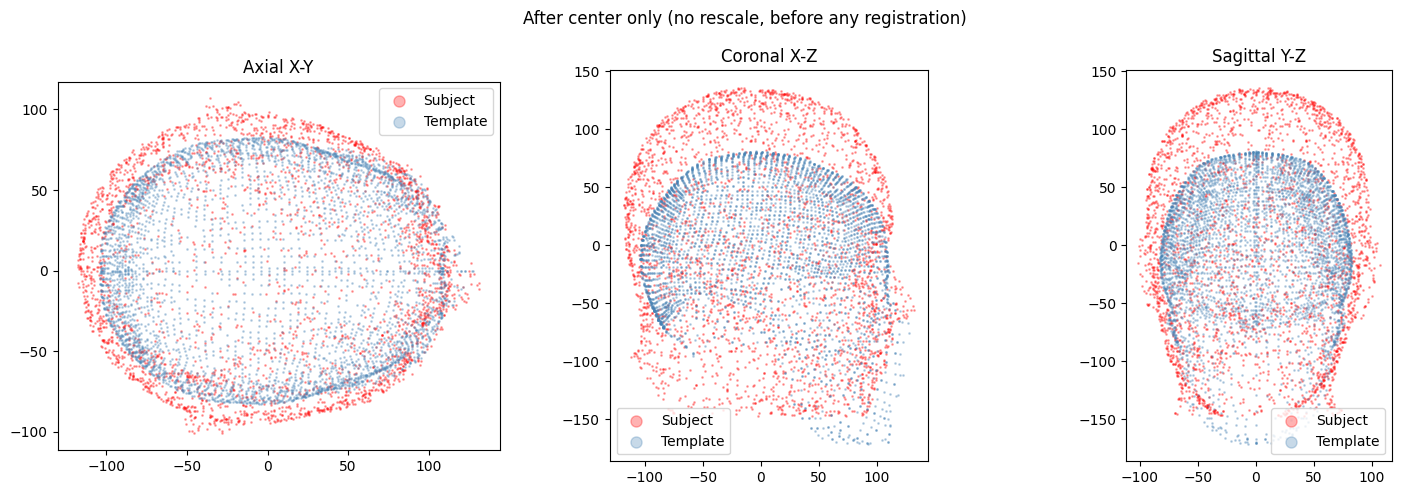

In [43]:
def center_only(fixed_pts, moving_pts):
    c_fixed  = fixed_pts.mean(0)
    c_moving = moving_pts.mean(0)
    f_c = fixed_pts - c_fixed
    m_c = moving_pts - c_moving
    scale = 1.0
    return f_c, m_c * scale, dict(c_fixed=c_fixed, c_moving=c_moving, scale=scale)

nf_c, nm_surf_cs, norm_params = center_only(subject_pts, skin_surf_pts0)
c_fixed, c_moving, scale = norm_params['c_fixed'], norm_params['c_moving'], norm_params['scale']
nm_all_cs = (all_pts0 - c_moving) * scale

print(f'Centroid (subject) : {c_fixed.round(1)}')
print(f'Centroid (template): {c_moving.round(1)}')
print(f'Scale factor        : {scale:.4f} (fixed, auto-rescale removed)')

def plot_overlap(a, b, title, labels=('Subject', 'Template'), n_sample=4000):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    views = [(0, 1, 'Axial X-Y'), (0, 2, 'Coronal X-Z'), (1, 2, 'Sagittal Y-Z')]
    sa = np.random.choice(len(a), min(n_sample, len(a)), replace=False)
    sb = np.random.choice(len(b), min(n_sample, len(b)), replace=False)
    for ax, (i, j, lbl) in zip(axes, views):
        ax.scatter(a[sa, i], a[sa, j], s=1, c='red', alpha=0.3, label=labels[0])
        ax.scatter(b[sb, i], b[sb, j], s=1, c='steelblue', alpha=0.3, label=labels[1])
        ax.set_title(lbl); ax.set_aspect('equal'); ax.legend(markerscale=8)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

plot_overlap(nf_c, nm_surf_cs, 'After center only (no rescale, before any registration)')

## Stage 0.5b — Landmark-seeded rigid alignment (Kabsch/Procrustes)

Uses matched landmarks (if present) to compute a rigid rotation, replacing
Stage 1's blind PCA search. No-op if landmark files don't exist.

Kabsch/Procrustes rigid seed from 10 matched landmark pairs
  Mean landmark residual before seed rotation: 31.23 (normalized units)
  Mean landmark residual after  seed rotation: 48.41 (normalized units)


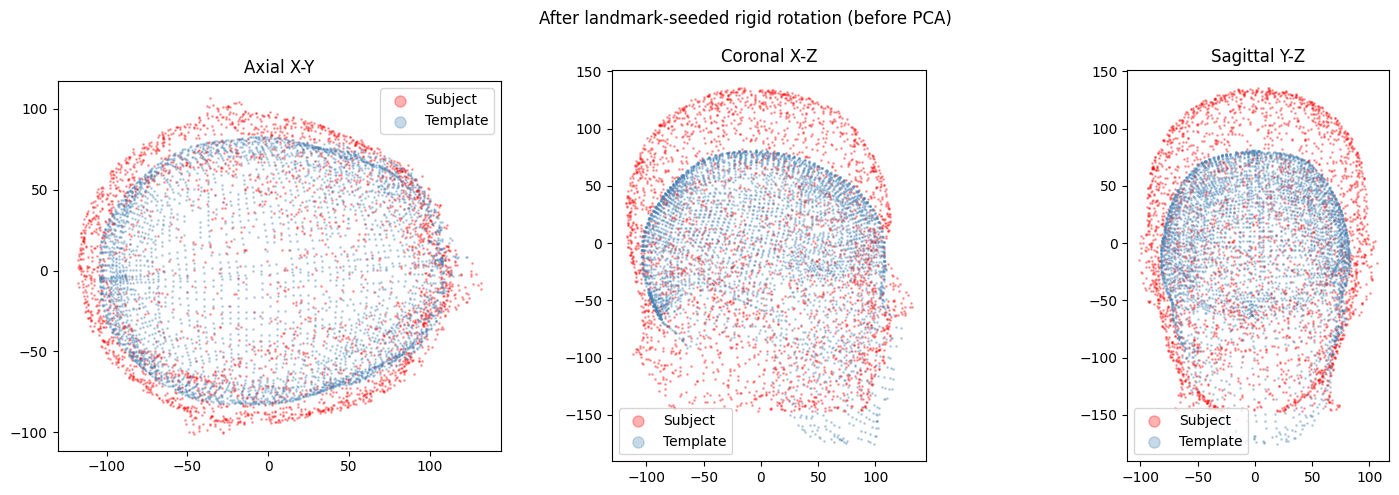

In [44]:
def kabsch_rotation(P, Q):
    """Rotation R (P @ R.T) mapping centered P onto centered Q."""
    Pc = P - P.mean(0)
    Qc = Q - Q.mean(0)
    H = Pc.T @ Qc
    U, S, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1, 1, d])
    R = Vt.T @ D @ U.T
    return R

if os.path.exists(TEMPLATE_MATCHED_LANDMARKS_PATH) and os.path.exists(SUBJECT_MATCHED_LANDMARKS_PATH):
    tmpl_lm_raw = np.load(TEMPLATE_MATCHED_LANDMARKS_PATH)
    subj_lm_raw = np.load(SUBJECT_MATCHED_LANDMARKS_PATH)
    assert tmpl_lm_raw.shape == subj_lm_raw.shape, \
        f'Matched landmark counts must match: {tmpl_lm_raw.shape} vs {subj_lm_raw.shape}'

    tmpl_lm_cs = (tmpl_lm_raw - c_moving) * scale
    subj_lm_cs = subj_lm_raw - c_fixed

    R_seed = kabsch_rotation(tmpl_lm_cs, subj_lm_cs)
    residual_before = np.linalg.norm(tmpl_lm_cs - subj_lm_cs, axis=1).mean()
    residual_after  = np.linalg.norm(tmpl_lm_cs @ R_seed.T - subj_lm_cs, axis=1).mean()
    print(f'Kabsch/Procrustes rigid seed from {len(tmpl_lm_raw)} matched landmark pairs')
    print(f'  Mean landmark residual before seed rotation: {residual_before:.2f} (normalized units)')
    print(f'  Mean landmark residual after  seed rotation: {residual_after:.2f} (normalized units)')

    nm_surf_cs = nm_surf_cs @ R_seed.T
    nm_all_cs  = nm_all_cs  @ R_seed.T
    landmark_seed_applied = True
    plot_overlap(nf_c, nm_surf_cs, 'After landmark-seeded rigid rotation (before PCA)')
else:
    landmark_seed_applied = False
    print('No matched landmark files found -- skipping seed rotation.')

## Stage 0.5 — Landmark subsampling (farthest-point sampling)

CPD cost is O(N·M) per iteration, so registration runs on a bounded landmark
subset; TPS (Stage 5) propagates the result to the full dense surface.

Fixed  (subject) landmarks : 2,000
Moving (template) landmarks: 2,000


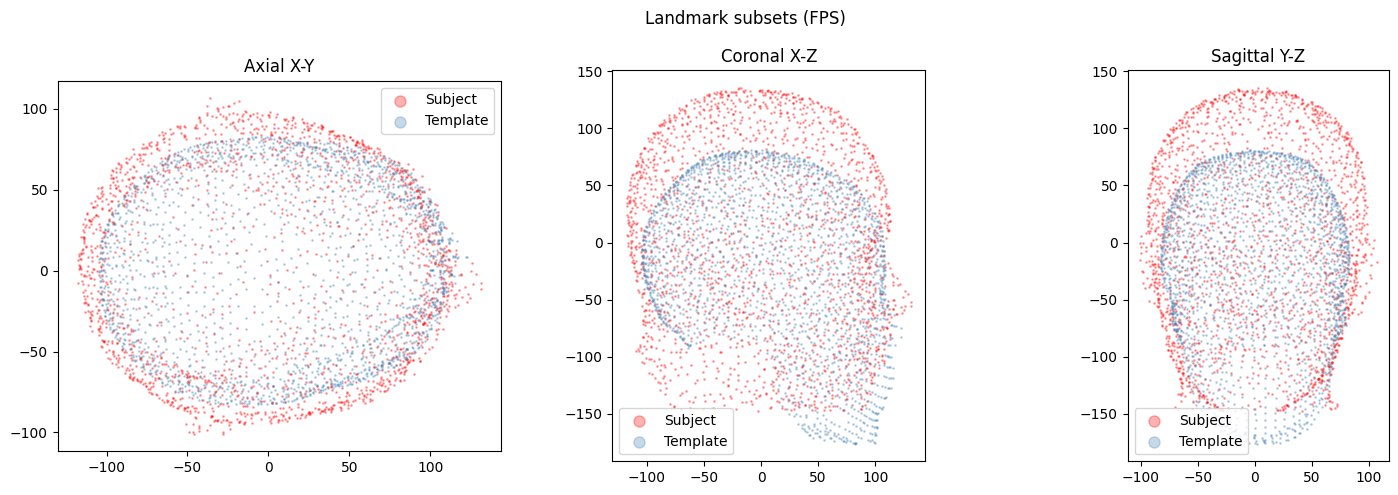

In [45]:
def farthest_point_sampling(points, n_samples, seed=0):
    rng = np.random.default_rng(seed)
    n = len(points)
    n_samples = min(n_samples, n)
    selected = np.empty(n_samples, dtype=np.int64)
    selected[0] = rng.integers(n)
    dist = np.linalg.norm(points - points[selected[0]], axis=1)
    for k in range(1, n_samples):
        selected[k] = np.argmax(dist)
        dist = np.minimum(dist, np.linalg.norm(points - points[selected[k]], axis=1))
    return selected

fixed_lm_idx  = farthest_point_sampling(nf_c, N_LANDMARKS_FIXED)
moving_lm_idx = farthest_point_sampling(nm_surf_cs, N_LANDMARKS_MOVING)

fixed_lm  = nf_c[fixed_lm_idx]
moving_lm = nm_surf_cs[moving_lm_idx]

print(f'Fixed  (subject) landmarks : {len(fixed_lm):,}')
print(f'Moving (template) landmarks: {len(moving_lm):,}')
plot_overlap(fixed_lm, moving_lm, 'Landmark subsets (FPS)')


## Stage 1 — PCA coarse pre-alignment

Skipped if `landmark_seed_applied` (Stage 0.5b's rotation is real
correspondence, better than PCA's blind symmetry guess).

landmark_seed_applied=True -- skipping PCA, R_pca = identity.


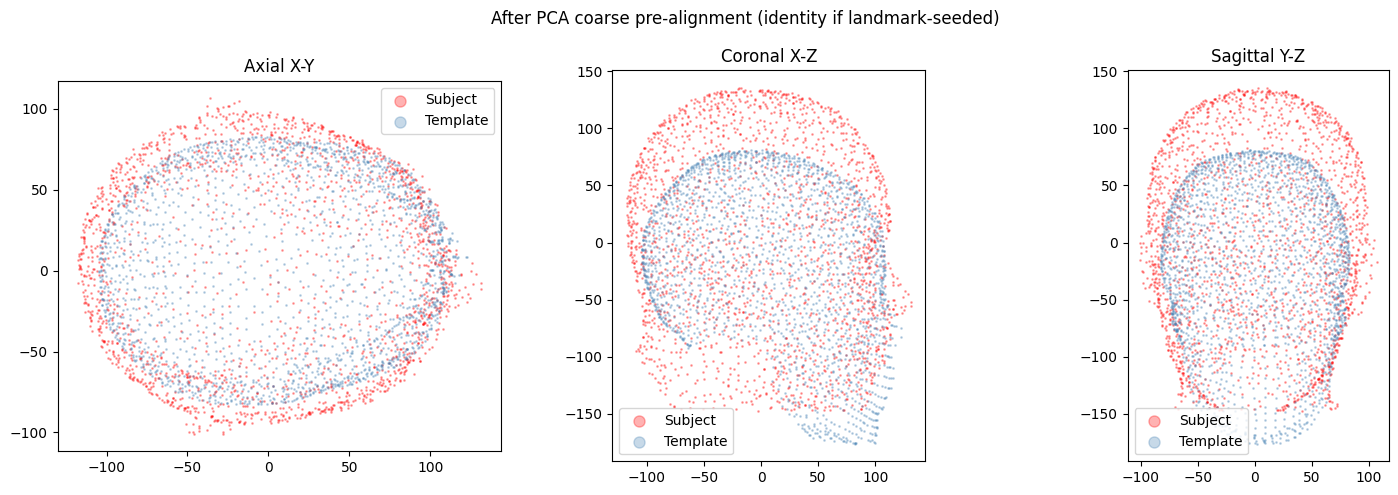

In [46]:
def pca_axes(pts):
    cov = np.cov(pts.T)
    w, v = np.linalg.eigh(cov)
    order = np.argsort(w)[::-1]
    return v[:, order]

def pca_prealign(fixed_pts, moving_pts, eval_stride=5):
    V_f = pca_axes(fixed_pts)
    V_m = pca_axes(moving_pts)
    tree = cKDTree(fixed_pts)
    best = None
    for s0 in (1, -1):
        for s1 in (1, -1):
            for s2 in (1, -1):
                S = np.diag([s0, s1, s2])
                R = V_f @ S @ V_m.T
                if np.linalg.det(R) < 0:
                    continue
                cand = moving_pts @ R.T
                d, _ = tree.query(cand[::eval_stride])
                score = d.mean()
                if best is None or score < best[0]:
                    best = (score, R)
    return best[1], best[0]

if landmark_seed_applied:
    R_pca = np.eye(3)
    pca_score = np.nan
    print('landmark_seed_applied=True -- skipping PCA, R_pca = identity.')
else:
    R_pca, pca_score = pca_prealign(fixed_lm, moving_lm)
    print(f'PCA pre-alignment rotation (best of 4 valid sign combinations):')
    print(np.round(R_pca, 3))
    print(f'Mean NN distance after PCA align: {pca_score:.2f} (normalized units)')

moving_lm_pca  = moving_lm  @ R_pca.T
nm_surf_pca    = nm_surf_cs @ R_pca.T
nm_all_pca     = nm_all_cs  @ R_pca.T

plot_overlap(fixed_lm, moving_lm_pca, 'After PCA coarse pre-alignment (identity if landmark-seeded)')

## Stage 2 — Rigid CPD

Rigid scale       : 1.1503
Rigid rotation R  :
[[ 0.976 -0.091 -0.2  ]
 [ 0.081  0.995 -0.058]
 [ 0.204  0.04   0.978]]
Rigid translation : [-3.89  1.72 27.89]


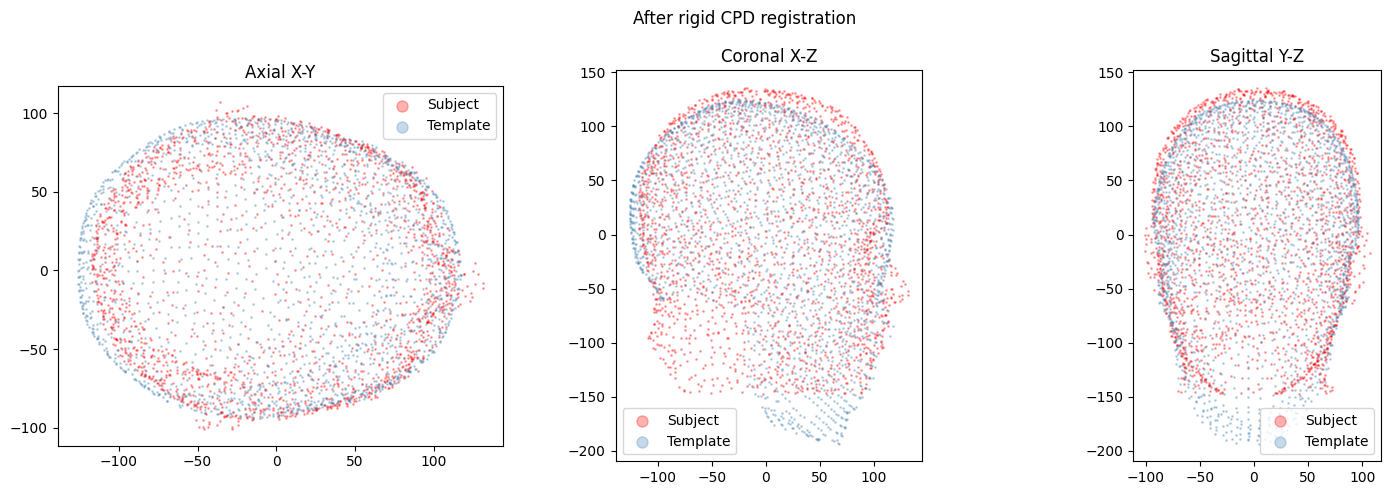

In [47]:
rigid_reg = RigidRegistration(X=fixed_lm, Y=moving_lm_pca, max_iterations=CPD_MAX_ITER, tolerance=CPD_TOL)
TY_rigid, (s_r, R_r, t_r) = rigid_reg.register()

print(f'Rigid scale       : {s_r:.4f}')
print(f'Rigid rotation R  :\n{np.round(R_r, 3)}')
print(f'Rigid translation : {np.round(t_r, 2)}')

plot_overlap(fixed_lm, TY_rigid, 'After rigid CPD registration')


## Stage 3 — Affine CPD

Affine matrix B (raw)    :
[[ 0.897  0.019  0.41 ]
 [-0.027  0.967 -0.045]
 [-0.153  0.014  1.18 ]]
Singular values (raw)    : [1.268 0.967 0.885]
Singular values (clamped): [1.25  0.967 0.885]
Affine translation: [-1.34  0.02 -5.77]


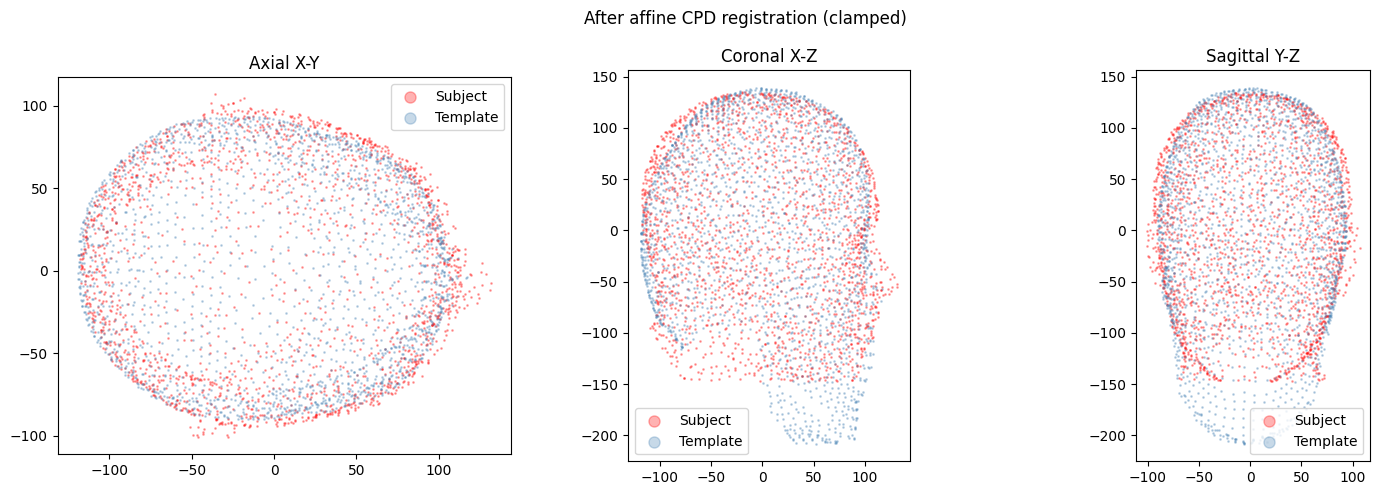

In [48]:
AFFINE_SINGULAR_VALUE_CLAMP = (0.8, 1.25)  # reject implausible shear/scale

affine_reg = AffineRegistration(X=fixed_lm, Y=TY_rigid, max_iterations=CPD_MAX_ITER, tolerance=CPD_TOL)
_, (B_a, t_a) = affine_reg.register()

U, S, Vt = np.linalg.svd(B_a)
S_clamped = np.clip(S, *AFFINE_SINGULAR_VALUE_CLAMP)
B_a_clamped = U @ np.diag(S_clamped) @ Vt
TY_affine = TY_rigid @ B_a_clamped + t_a

print(f'Affine matrix B (raw)    :\n{np.round(B_a, 3)}')
print(f'Singular values (raw)    : {np.round(S, 3)}')
print(f'Singular values (clamped): {np.round(S_clamped, 3)}')
print(f'Affine translation: {np.round(t_a, 2)}')

plot_overlap(fixed_lm, TY_affine, 'After affine CPD registration (clamped)')

## Stage 4 — Non-rigid (deformable) CPD

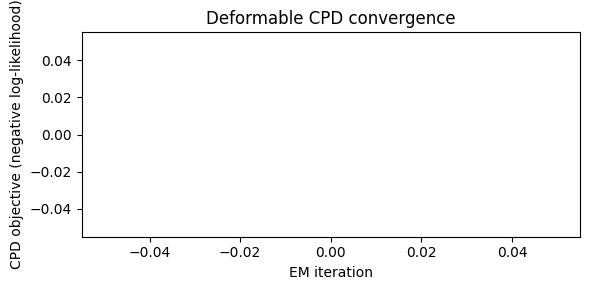

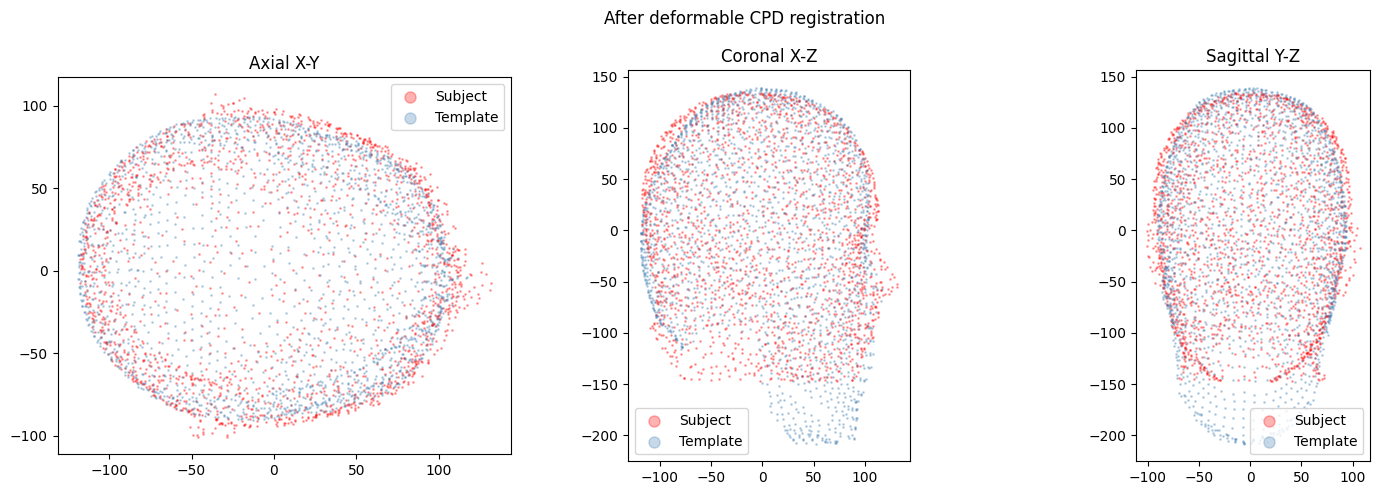

In [49]:
cpd_errors = []
def _track(iteration, error, X, Y):
    cpd_errors.append(error)

deformable_reg = DeformableRegistration(X=fixed_lm, Y=TY_affine,
                                         alpha=CPD_ALPHA, beta=CPD_BETA,
                                         max_iterations=CPD_MAX_ITER, tolerance=CPD_TOL)
TY_cpd, (G, W) = deformable_reg.register(callback=_track)

plt.figure(figsize=(6, 3))
plt.plot(cpd_errors)
plt.xlabel('EM iteration'); plt.ylabel('CPD objective (negative log-likelihood)')
plt.title('Deformable CPD convergence'); plt.tight_layout(); plt.show()

plot_overlap(fixed_lm, TY_cpd, 'After deformable CPD registration')


## Stage 5 — TPS propagation (skin field pushed onto the whole head)

Fit TPS on Stage-4 landmark displacements, evaluate on both the dense skin
surface and the whole mesh.

Warped dense skin surface: 6,182 nodes
Warped whole head model  : 179,676 nodes


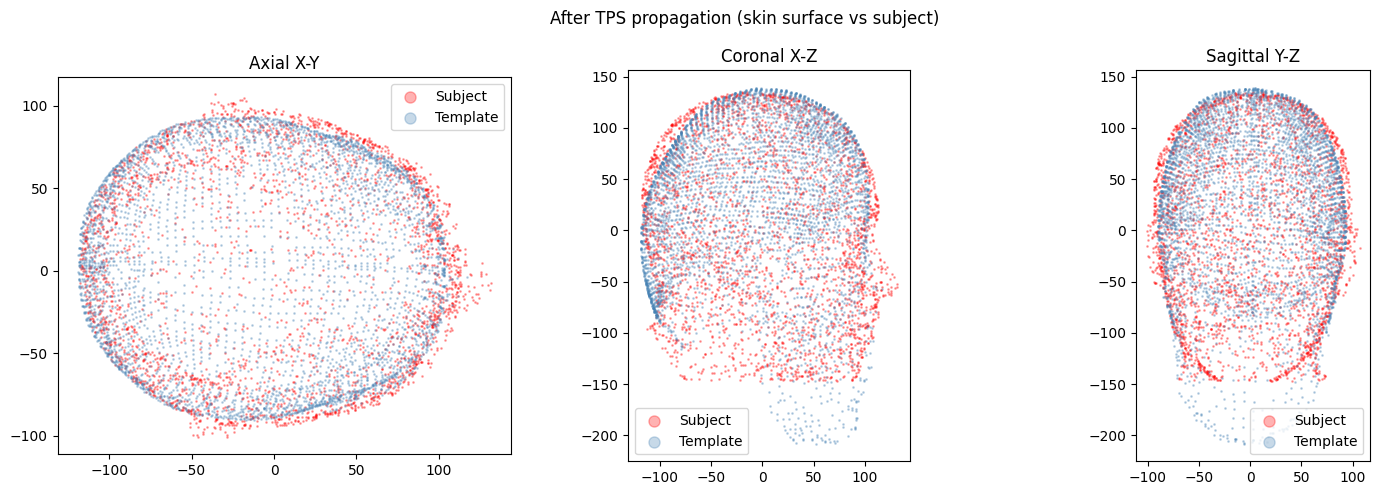

In [50]:
tps = RBFInterpolator(moving_lm, TY_cpd, kernel='thin_plate_spline', smoothing=TPS_SMOOTHING)

nm_surf_warped_cs = tps(nm_surf_pca)
all_warped_cs = tps(nm_all_pca)

print(f'Warped dense skin surface: {nm_surf_warped_cs.shape[0]:,} nodes')
print(f'Warped whole head model  : {all_warped_cs.shape[0]:,} nodes')
plot_overlap(nf_c, nm_surf_warped_cs, 'After TPS propagation (skin surface vs subject)')

## [Not implemented] Cavity-constraint / SDF correction

No check for brain/skull interpenetration. `k_mesh_qa.py` catches
per-element folding only, not cross-tissue overlap. Needs to be added if
that matters for solver use.

## Stage 6 — Non-rigid ICP refinement (lightweight)

Pull each warped skin point toward its nearest subject point, k-NN smoothed.
Simplified stand-in for Amberg et al. (2007).

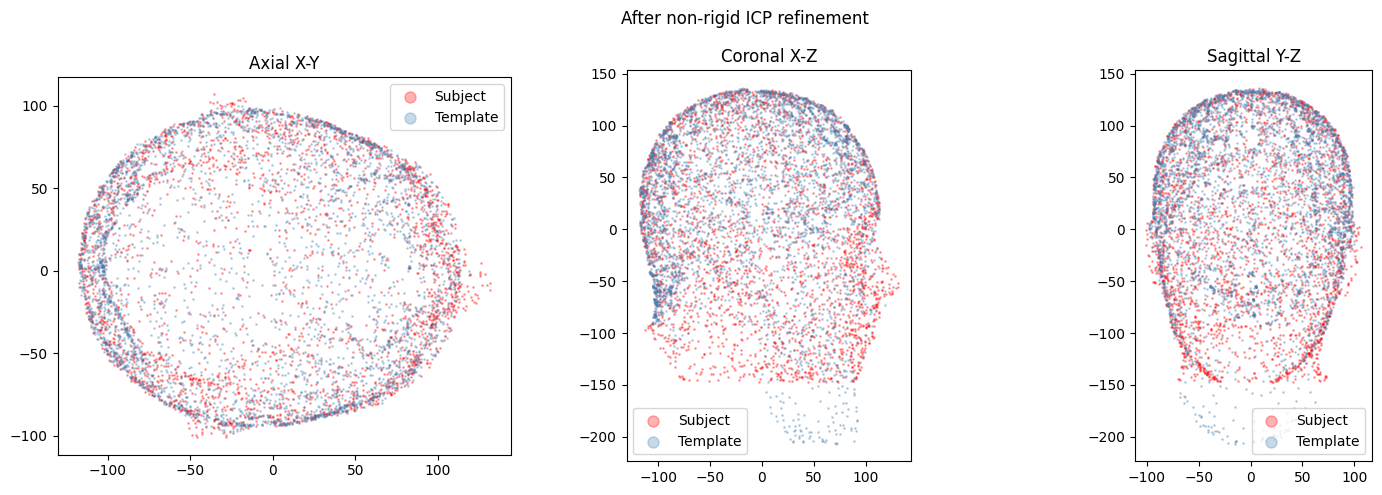

In [51]:
def graph_smooth(vectors, points, k=8, iters=1):
    tree = cKDTree(points)
    _, idx = tree.query(points, k=k + 1)  # includes self
    smoothed = vectors.copy()
    for _ in range(iters):
        smoothed = smoothed[idx].mean(axis=1)
    return smoothed

def nonrigid_icp_refine(source_pts, target_pts, iters, max_corr_dist_mm, step, scale, k_smooth):
    pts = source_pts.copy()
    tree_t = cKDTree(target_pts)
    for it in range(iters):
        d, nn_idx = tree_t.query(pts)
        pull = target_pts[nn_idx] - pts
        valid = (d / scale) < max_corr_dist_mm   # scale converts normalized units back to mm
        pull[~valid] = 0.0
        pull_smooth = graph_smooth(pull, pts, k=k_smooth)
        pts = pts + step * pull_smooth
    return pts

nm_surf_icp_cs = nonrigid_icp_refine(
    nm_surf_warped_cs, nf_c,
    iters=ICP_ITERS, max_corr_dist_mm=ICP_MAX_CORR_DIST_MM,
    step=ICP_STEP, scale=scale, k_smooth=ICP_SMOOTH_NEIGHBORS,
)

plot_overlap(nf_c, nm_surf_icp_cs, 'After non-rigid ICP refinement')


## Stage 6.5 -- Confidence-damped blend (do-no-harm safeguard)

Blends toward whichever of (warped, original) is closer to the subject
surface, per point, spatially smoothed so neighbors don't diverge (avoids
mesh spikes/self-intersection).

Warp kept in full (warp was better)  : 3,299 / 6,182 points
Reverted to original (original was better): 71 / 6,182 points
Partially blended                     : 2,812 / 6,182 points
Confidence changed by smoothing -- mean 0.046, max 0.802, 1,033 points shifted by >0.1
Do-no-harm check -- mean residual: original=18.64mm  warped=4.28mm  blended=3.91mm
                     max residual : original=53.26mm  warped=66.95mm  blended=36.47mm


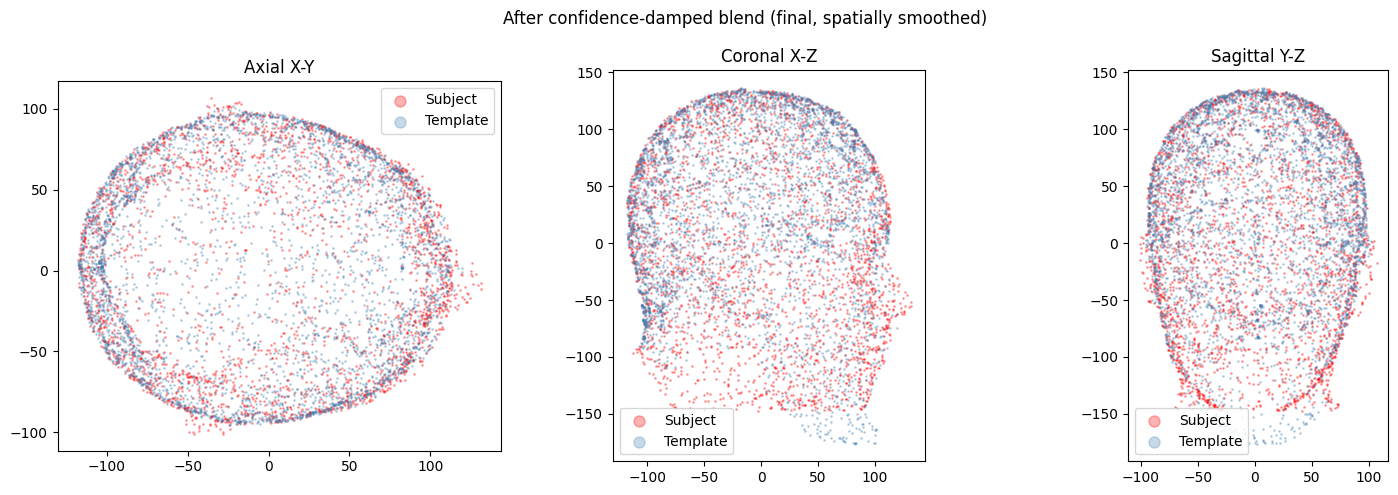

In [52]:
BLEND_TRANSITION_MM = 10.0
CONF_SMOOTH_NEIGHBORS = 8
CONF_SMOOTH_ITERS = 3

def coverage_damped_blend(original_pts, warped_pts, target_pts, scale,
                           transition_mm=BLEND_TRANSITION_MM,
                           smooth_k=CONF_SMOOTH_NEIGHBORS, smooth_iters=CONF_SMOOTH_ITERS):
    tree_t = cKDTree(target_pts)
    d_orig_mm, _   = tree_t.query(original_pts)
    d_warped_mm, _ = tree_t.query(warped_pts)
    d_orig_mm   /= scale
    d_warped_mm /= scale

    # per-point confidence in the warp: 1 = warp better, 0 = original better
    advantage = d_orig_mm - d_warped_mm
    confidence_raw = np.clip(advantage / transition_mm + 0.5, 0.0, 1.0)

    # smooth confidence spatially so neighbors don't diverge
    tree_p = cKDTree(warped_pts)
    _, knn_idx = tree_p.query(warped_pts, k=smooth_k + 1)
    confidence = confidence_raw.copy()
    for _ in range(smooth_iters):
        confidence = confidence[knn_idx].mean(axis=1)

    blended = original_pts + confidence[:, None] * (warped_pts - original_pts)

    d_blended_mm, _ = tree_t.query(blended)
    d_blended_mm /= scale
    return blended, confidence, confidence_raw, d_orig_mm, d_warped_mm, d_blended_mm

nm_surf_final_cs, coverage_conf, coverage_conf_raw, d_orig_mm, d_warped_mm, d_blended_mm = coverage_damped_blend(
    nm_surf_pca, nm_surf_icp_cs, nf_c, scale)

n_warp_kept = int((coverage_conf >= 0.999).sum())
n_reverted  = int((coverage_conf <= 0.001).sum())
n_blend     = len(coverage_conf) - n_warp_kept - n_reverted
print(f'Warp kept in full (warp was better)  : {n_warp_kept:,} / {len(coverage_conf):,} points')
print(f'Reverted to original (original was better): {n_reverted:,} / {len(coverage_conf):,} points')
print(f'Partially blended                     : {n_blend:,} / {len(coverage_conf):,} points')

conf_delta = np.abs(coverage_conf - coverage_conf_raw)
print(f'Confidence changed by smoothing -- mean {conf_delta.mean():.3f}, max {conf_delta.max():.3f}, '
      f'{(conf_delta > 0.1).sum():,} points shifted by >0.1')

print(f'Do-no-harm check -- mean residual: original={d_orig_mm.mean():.2f}mm  warped={d_warped_mm.mean():.2f}mm  blended={d_blended_mm.mean():.2f}mm')
print(f'                     max residual : original={d_orig_mm.max():.2f}mm  warped={d_warped_mm.max():.2f}mm  blended={d_blended_mm.max():.2f}mm')

plot_overlap(nf_c, nm_surf_final_cs, 'After confidence-damped blend (final, spatially smoothed)')

## Stage 7 — Validation & summary

In [53]:
def surface_agreement(source_pts, target_pts, scale):
    tree_t = cKDTree(target_pts)
    tree_s = cKDTree(source_pts)
    d_s2t, _ = tree_t.query(source_pts)
    d_t2s, _ = tree_s.query(target_pts)
    d_s2t /= scale; d_t2s /= scale
    chamfer = d_s2t.mean() + d_t2s.mean()
    hausdorff = max(d_s2t.max(), d_t2s.max())
    return dict(mean=d_s2t.mean(), median=np.median(d_s2t), rms=np.sqrt((d_s2t**2).mean()),
                max=d_s2t.max(), chamfer=chamfer, hausdorff=hausdorff)

rows = []
for stage, pts in [
    ('0. Center+resize',        moving_lm),
    ('1. PCA pre-align',        moving_lm_pca),
    ('2. Rigid CPD',            TY_rigid),
    ('3. Affine CPD',           TY_affine),
    ('4. Non-rigid CPD',        TY_cpd),
    ('5. TPS (dense surface)',  nm_surf_warped_cs),
    ('6. Non-rigid ICP',         nm_surf_icp_cs),
    ('6.5 Confidence blend (final)', nm_surf_final_cs),
]:
    rows.append(dict(stage=stage, **surface_agreement(pts, nf_c, scale)))

summary_df = pd.DataFrame(rows).round(3)
summary_df


,stage,mean,median,rms,max,chamfer,hausdorff
0,0. Center+resize,17.435,12.502,21.775,52.916,39.416,67.395
1,1. PCA pre-align,17.435,12.502,21.775,52.916,39.416,67.395
2,2. Rigid CPD,8.443,7.025,10.751,49.554,17.851,72.475
3,3. Affine CPD,9.613,6.869,14.225,66.946,17.656,66.946
4,4. Non-rigid CPD,9.587,6.847,14.206,66.946,17.570,66.946
5,5. TPS (dense surface),7.730,6.618,10.218,66.946,14.899,66.946
6,6. Non-rigid ICP,4.276,3.195,7.827,66.946,8.270,66.946
7,6.5 Confidence blend (final),3.907,3.323,5.187,36.466,8.090,49.029


NameError: name 'summary_df' is not defined

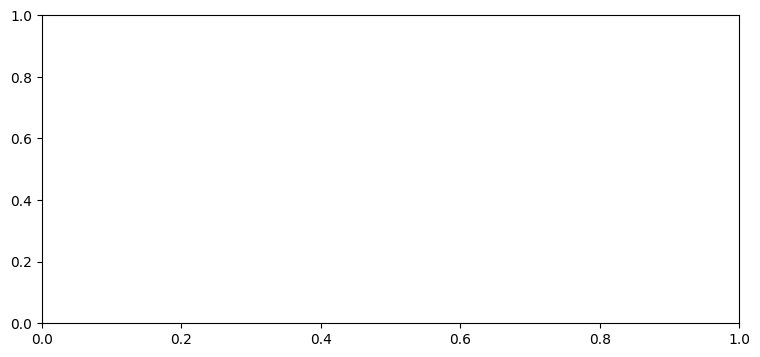

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(summary_df['stage'], summary_df['hausdorff'], color='steelblue', alpha=0.85)
ax.set_ylabel('Hausdorff distance to subject surface (mm)')
ax.set_title('Registration quality by stage (lower = better)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()

improvement = (summary_df.iloc[0]['hausdorff'] - summary_df.iloc[-1]['hausdorff']) / summary_df.iloc[0]['hausdorff'] * 100
print(f"Hausdorff distance: {summary_df.iloc[0]['hausdorff']:.2f} mm -> {summary_df.iloc[-1]['hausdorff']:.2f} mm "
      f"({improvement:.1f}% reduction)")
print(f"Final Hausdorff distance: {summary_df.iloc[-1]['hausdorff']:.2f} mm")


## Save outputs -- write a `.vtu`

Every node updated. Stage 5b rebuilds TPS from the refined skin
correspondence and evaluates it on the whole mesh; skin's own nodes are then
overwritten with their directly-computed (better) position. Re-centers on
`c_fixed` (subject centroid), not the template's.

In [55]:
def to_world(pts_cs_pca):
    pts_cs = pts_cs_pca @ np.linalg.inv(R_pca).T
    return (pts_cs / scale) + c_fixed

# Stage 5b -- rebuild TPS from the fully refined skin correspondence, apply to whole mesh
tps_final = RBFInterpolator(nm_surf_pca, nm_surf_final_cs, kernel='thin_plate_spline', smoothing=TPS_SMOOTHING)
all_final_cs = tps_final(nm_all_pca)

final_world_coords = to_world(all_final_cs)
skin_world_coords   = to_world(nm_surf_final_cs)  # skin's own directly-computed position

updated_coords = {int(nid): xyz for nid, xyz in zip(all_node_ids, final_world_coords)}
updated_coords.update({int(nid): xyz for nid, xyz in zip(skin_surf_node_ids, skin_world_coords)})
print(f'Nodes to update: {len(all_node_ids):,} (whole head model), '
      f'{len(skin_surf_node_ids):,} of which overwritten with the skin-specific refined result')

node_id_to_idx = {int(nid): idx for idx, nid in enumerate(template_mesh.point_data['node_id'])}

final_mesh = template_mesh.copy()
new_points = final_mesh.points.copy()
for nid, xyz in updated_coords.items():
    new_points[node_id_to_idx[nid]] = xyz
final_mesh.points = new_points

OUTPUT_VTU = os.path.join(OUTPUT_DIR, 'Head_V6_skin_registered_v3.vtu')
final_mesh.save(OUTPUT_VTU)
print(f'Wrote -> {OUTPUT_VTU}')

out_csv = os.path.join(OUTPUT_DIR, 'validation_summary_v2.csv')
summary_df.to_csv(out_csv, index=False)
print(f'Wrote -> {out_csv}')

Nodes to update: 179,676 (whole head model), 6,182 of which overwritten with the skin-specific refined result
Wrote -> /home/asusry7/Desktop/New_version/New_version/Data/outputs/cpd_tps_skin_registration/Head_V6_skin_registered_v3.vtu
Wrote -> /home/asusry7/Desktop/New_version/New_version/Data/outputs/cpd_tps_skin_registration/validation_summary_v2.csv


## QA the written mesh (k_mesh_qa.py)

Checks for inverted/degenerate elements. Doesn't catch cross-tissue
interpenetration.

In [56]:
sys.path.insert(0, os.path.join(BASE_DIR, 'Code/python'))
from k_mesh_qa import parse_k_file, check_mesh

nodes_orig, elems_solid_orig, elems_shell_orig = parse_k_file(TEMPLATE_K)

# Every node updated now (whole head model), not just a subset
nodes_new = dict(nodes_orig)
nodes_new.update(updated_coords)

print(f'Node count  -> original: {len(nodes_orig):,}, updated: {len(nodes_new):,}')
print(f'Solid elems : {len(elems_solid_orig):,}   Shell elems: {len(elems_shell_orig):,}  (topology unchanged)')

result = check_mesh(nodes_new, elems_solid_orig, label=OUTPUT_VTU, elems_shell=elems_shell_orig)

# Confirm every node that should have moved actually differs from original
moved_ok = all(not np.array_equal(nodes_orig[nid], nodes_new[nid]) for nid in updated_coords)
print(f'\nAll updated nodes actually differ from original: {moved_ok}')

Node count  -> original: 179,676, updated: 179,676
Solid elems : 176,441   Shell elems: 80,130  (topology unchanged)

MESH QA: /home/asusry7/Desktop/New_version/New_version/Data/outputs/cpd_tps_skin_registration/Head_V6_skin_registered_v3.vtu
  Nodes   : 179676
  Elements (solid/tshell): 176441
  Elements (shell)       : 80130

  NOTE: 43 of 83 parts show a mixed sign split
  internally (checked per-PID, not whole-mesh) -- flagging only the
  minority winding within each part as suspect.

  Inverted elements (negative volume): 7334
  Near-zero volume (degenerate)       : 0
  Volume stats -> min: 1.115542e-04, median: 6.082558e+00, max: 1.233841e+03
  Max/min volume ratio (proxy for aspect distortion): 1.11e+07
  ⚠ WARNING: high volume ratio -> expect LS-DYNA timestep collapse

  ⚠ FAILING ELEMENT IDs (first 20): [88058794, 88064519, 88064524, 88064533, 88064549, 88064552, 88064581, 88064627, 88064641, 88064644, 88064699, 88064715, 88064716, 88064760, 88065277, 88065280, 88065295, 88067